<a href="https://colab.research.google.com/github/Daniel-EDC/StudentPerformanceModel/blob/main/HandsOn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# dataset has 15 columns and 2392 students
df = pd.read_csv("Student_performance_data _.csv")

#Note, this is to delete Gradeclass if GPA is what I am after
df = df.drop(columns=["GradeClass"]) #It is the opposite of GPA

#Other notes: Ethnicity (0=Caucasian, 1=African American, 2=Asian, 3=Other);
#             ParentalEducation (0=None, 1=High School, 2=Some College, 3=Bachelor’s, 4=Higher); ParentalSupport (0=None, 1=Low, 2=Moderate, 3=High, 4=Very High).

# Head of dataset
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061


In [54]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (2392, 14)

Columns:
 Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA'],
      dtype='object')

Data Types:

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
dtype: object


In [55]:
df.describe(include='all') #statistics

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [56]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values in each Column:\n")
print(missing_values)

#no missing values

Missing Values in each Column:

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
dtype: int64


In [57]:
print("Number of duplicate rows is:", df.duplicated().sum())# no duplicate rows

Number of duplicate rows is: 0


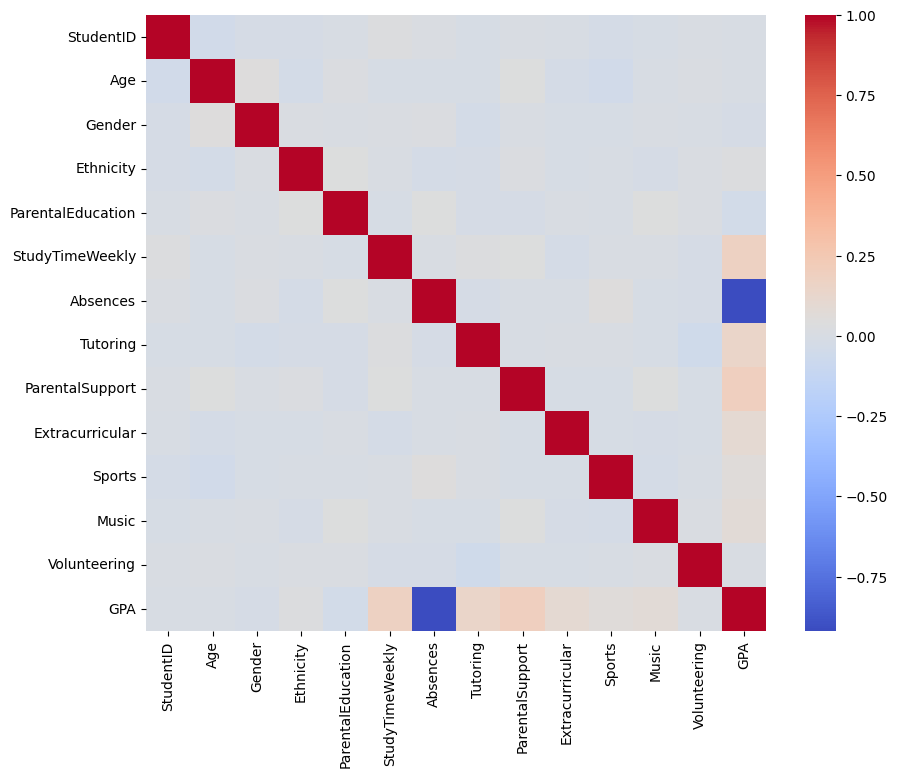

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
# this is a correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.show()

#this shows that Abscneces is blue beucase its bad(so look for no), and tutoring, studytime, and parental support are redish

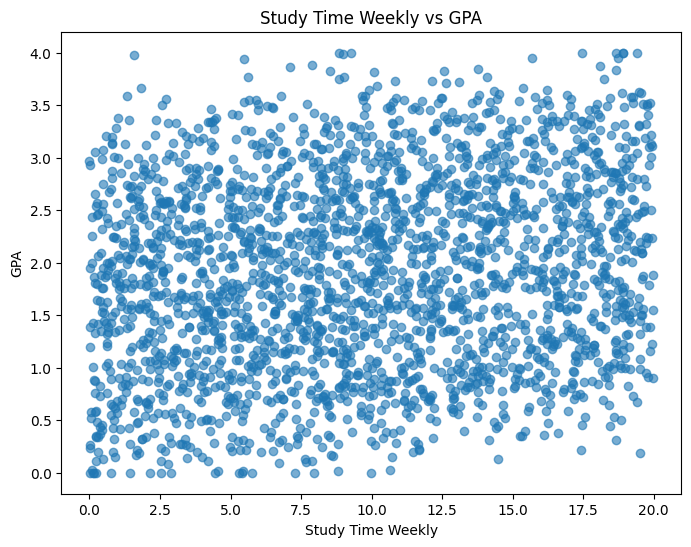

In [59]:
#practice scattergraph:

import matplotlib.pyplot as plt #imot

plt.figure(figsize=(8,6))
plt.scatter(df['StudyTimeWeekly'], df['GPA'], alpha=0.6)
plt.xlabel('Study Time Weekly')
plt.ylabel('GPA')
plt.title('Study Time Weekly vs GPA')
plt.show()

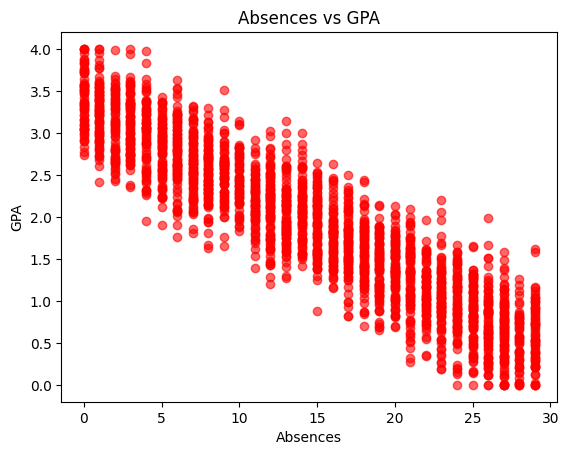

In [60]:
# The best one is absences

plt.scatter(df['Absences'], df['GPA'], alpha=0.6, color='red')
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.title('Absences vs GPA')
plt.show()

#this one is better becuase it shows a pattern and relationship

In [61]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(df[['Absences']], df['GPA'])

print("Many Absences")
reg.predict([[10]]) # the less, the better the GPA

Many Absences


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([2.35741463])

In [62]:
print("Few Absences")
reg.predict([[2]])

Few Absences


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.15228762])

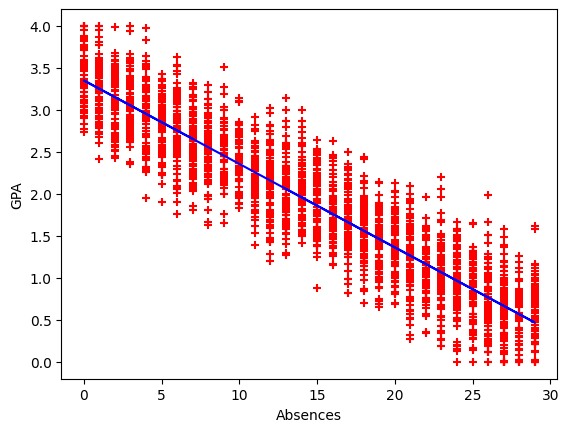

In [63]:
# Scatter plot
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.scatter(df['Absences'], df['GPA'], color='red', marker='+')

# Regression line
plt.plot(df['Absences'], reg.predict(df[['Absences']]), color='blue')
# uses Absences as the input to predict GPA, because GPA is what the model was trained to predict

plt.show()

In [64]:
#this is the predictions that is for the first algorithm
import pandas as pd

# load as d
d = pd.read_csv("Student_performance_data _.csv")

# Make predictions for p
p = reg.predict(d[['Absences']])

# Add predictions to dataframe
d['Predicted-GPA'] = p

# Save results
d.to_csv('predictions.csv', index=False)

# Head the results
e = pd.read_csv("predictions.csv")
e.head()
#sent to other excel sheet

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,Predicted-GPA
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,2.655492
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,3.351006
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,0.767669
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,1.959978
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,1.661901


In [65]:
import pandas as pd

# Load your dataset (change filename if needed)
#df = pd.read_csv("students.csv")

# Features (X) and Target (y)
X = df[['Absences', 'StudyTimeWeekly']]   # chose the predictors
y = df['GPA']   # target is GPA

# Split dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Here is the Linear Regression model
from sklearn.linear_model import LinearRegression #(again)

clf = LinearRegression()
clf.fit(X_train, y_train)


LinearRegression()

In [66]:
# Now for the Make predictions
y_pred = clf.predict(X_test)
y_pred

array([0.64431916, 2.3738665 , 2.8788663 , 3.42595239, 0.94532509,
       2.77128614, 0.99619679, 1.82148332, 1.769813  , 2.86821078,
       1.9678067 , 0.74323055, 1.35456686, 2.34322682, 1.05922205,
       3.074656  , 3.11505269, 1.7271333 , 1.79733377, 3.41231165,
       3.27772679, 3.24511782, 2.26875991, 2.75283121, 2.19983749,
       1.56318963, 1.27493715, 1.69818759, 2.65708671, 3.0567941 ,
       1.26366019, 1.66476827, 0.99172914, 2.96152679, 1.02211108,
       3.08453118, 1.12467773, 1.7711448 , 2.05686556, 2.12960017,
       2.76414666, 3.21348221, 2.75347562, 2.08829413, 2.52974107,
       1.16299067, 2.56877853, 2.24433247, 2.511053  , 0.92573923,
       2.33639287, 2.73668703, 2.39457561, 0.73646047, 0.57665436,
       1.5279076 , 2.67215201, 0.48281939, 1.55620776, 2.59029959,
       0.94306159, 2.34978656, 1.39898474, 1.63255555, 1.45154512,
       0.66291172, 2.32364006, 2.59909277, 0.25617576, 2.12980208,
       2.92907621, 1.89841283, 0.76725084, 1.05476315, 2.12885

In [67]:
#  Check score
print("The Score: ", clf.score(X_test, y_test))

The Score:  0.8881872164425899


In [68]:
# Need a Pass or Fail column based on GPA
df["Pass"] = np.where(df["GPA"] >= 2.5, 1, 0)

# The passs or faill
X = df.drop(columns=["GPA", "Pass"])
y = df["Pass"]

# test and train
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Here is the Linear Regression model
from sklearn.linear_model import LinearRegression #(again)

clf = LinearRegression()
clf.fit(X_train, y_train)


LinearRegression()

In [69]:
# Now for the Make predictions
y_pred = clf.predict(X_test)
y_pred

array([ 4.79341717e-01,  5.99268616e-01,  3.42535270e-01, -2.36534225e-03,
       -1.10852236e-01,  3.22575679e-01,  6.69159393e-01,  1.36582410e-01,
       -1.33541117e-01,  5.97222578e-02,  2.25812047e-01, -3.85183239e-01,
        3.35318837e-01,  9.09162892e-01,  2.57191623e-01,  2.64447359e-01,
        4.13451294e-01, -9.61474910e-02,  3.36707792e-01,  3.57860845e-01,
        1.77235588e-01,  5.66284631e-01,  3.18527643e-02,  6.57010666e-01,
        6.60955145e-02,  2.73609544e-01,  6.09303816e-02,  3.50878248e-01,
        1.52932936e-01,  4.55869176e-01,  1.49286447e-01,  4.15569451e-01,
        7.42955995e-01,  9.76491874e-01, -7.77104438e-02,  2.90831998e-01,
        9.60576640e-02,  1.81103998e-01, -3.02959042e-01, -1.63992744e-01,
        2.94340609e-01,  2.04695399e-02,  6.09656447e-01, -4.23607476e-01,
        3.58262765e-01,  2.29694143e-01,  7.35591068e-01, -1.01573886e-01,
        7.61806606e-01, -7.53738871e-02,  1.95058110e-01, -3.32992547e-02,
        2.07504611e-01,  

In [70]:
#  Check score
print("The Score: ", clf.score(X_test, y_test))

The Score:  0.6038541374101177


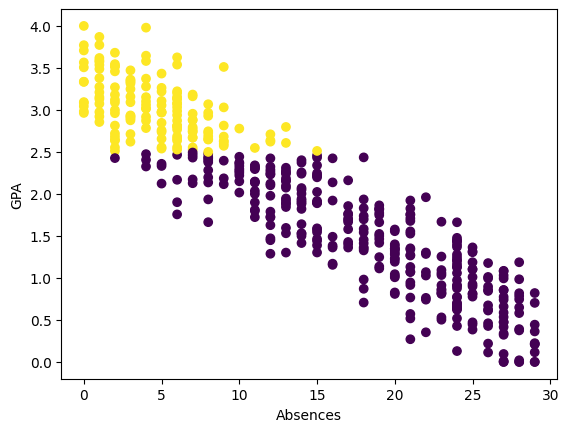

In [75]:
# Actual Pass/Fail
plt.scatter(df.loc[X_test.index, "Absences"], df.loc[X_test.index, "GPA"], c=y_test)
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()

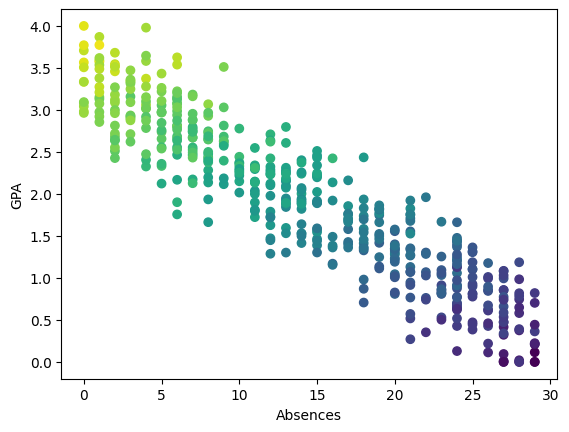

In [73]:
# The Predicted Pass/Fail
plt.scatter(df.loc[X_test.index, "Absences"], df.loc[X_test.index, "GPA"], c=y_pred)
plt.xlabel("Absences")
plt.ylabel("GPA")
plt.show()

In [43]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [44]:
from sklearn.metrics import confusion_matrix

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm

array([[308,  24],
       [ 59,  88]])

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred) )

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       332
           1       0.79      0.60      0.68       147

    accuracy                           0.83       479
   macro avg       0.81      0.76      0.78       479
weighted avg       0.82      0.83      0.82       479

